# 2/15   Урок 2. Доверительные интервалы


## Доверительный интервал для среднего нормальной популяции


Рассмотрим, как именно строится доверительный интервал для среднего нормального распределения. Начнём с простейшей ситуации — когда известна дисперсия $\sigma^2$.

In [108]:
import numpy as np
from scipy.stats import norm

np.random.seed(1)
n = 25
mu_true = 5.0
sigma = 2.0  # известно
data = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = data.mean()
alpha = 0.05
z = norm.ppf(1 - alpha/2)
ci_lower = xbar - z * sigma / np.sqrt(n)
ci_upper = xbar + z * sigma / np.sqrt(n)
print(f"x̄ = {xbar:.3f}, {100*(1-alpha):.0f}% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

x̄ = 4.975, 95% CI = [4.191, 5.759]


Когда генеральная дисперсия $\sigma^2$ неизвестна — что в реальности происходит почти всегда, её приходится оценивать по выборке. В этом случае распределение статистики уже нельзя считать строго нормальным, оно будет подчиняться распределению Стьюдента — и доверительный интервал будет строиться на его основе.

In [109]:
from scipy.stats import t

s = data.std(ddof=1)
t_q = t.ppf(1 - alpha/2, df=n-1)
ci_t = (xbar - t_q * s / np.sqrt(n), xbar + t_q * s / np.sqrt(n))
print(f"{100*(1-alpha):.0f}% t-CI = [{ci_t[0]:.3f}, {ci_t[1]:.3f}]")

95% t-CI = [4.068, 5.881]


Обратите внимание, если точно известно $\sigma$, то следует выбирать первый вариант. В реальности это редко случается, поэтому на практике чаще приходится использовать t. При больших $n$ (обычно $n\gtrsim 30$) t и z почти совпадают из-за сходимости t к нормали.

## Интервалы для дисперсии $\chi^2$

Помимо оценки среднего, часто важно понять, каков разброс в самих данных — то есть оценить дисперсию генеральной совокупности. Как и для среднего, вместо одной точечной оценки $s^2$ можно построить доверительный интервал для истинной дисперсии $\sigma^2$.

В случае нормальной выборки существует точное соотношение между выборочной и генеральной дисперсией, которое выражается через распределение $\chi^2$ (хи-квадрат). Это позволяет построить интервал, в котором с вероятностью $(1 - \alpha)$ лежит истинная дисперсия.

In [110]:
from scipy.stats import chi2

chi2_low = chi2.ppf(alpha/2, df=n-1)
chi2_high = chi2.ppf(1-alpha/2, df=n-1)
ci_var = ((n-1)*s*s / chi2_high, (n-1)*s*s / chi2_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print(f"CI for sigma^2: [{ci_var[0]:.3f}, {ci_var[1]:.3f}]")
print(f"CI for sigma: [{ci_sigma[0]:.3f}, {ci_sigma[1]:.3f}]")

CI for sigma^2: [2.941, 9.335]
CI for sigma: [1.715, 3.055]


## Интервалы для доли


Во многих задачах нас интересует не среднее или дисперсия, а доля успехов — т.е. вероятность наступления события. Например, доля покупателей, совершивших покупку, или доля бракованных деталей в партии.

Пусть $X\sim\operatorname{Bin}(n,p)$, наблюдаем число успехов $k$. Популярный (но ненадёжный при малых $n$ или $p$ близких к 0/1) — Wald-интервал рассчитывается как:

$\hat p = \frac{k}{n}, \quad \hat p \pm z_{1-\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}}$

Лучше использовать Agresti–Coull интервал — он практически всегда надёжен и рассчитывается как:

$\tilde n = n + z^2, \quad \tilde p = \frac{k + z^2/2}{\tilde n}$

Реализуем интервалы для доли на Python — встроенных методов в scipy на этот раз нет, поэтому сделаем расчёт вручную по формулам:

In [111]:
import numpy as np
from scipy.stats import norm

k = 45       # число успехов
n = 100      # число испытаний
alpha = 0.05 # уровень значимости

# Квантиль нормального распределения
z = norm.ppf(1 - alpha/2)

# Wald-интервал
p_hat = k / n
wald_lower = p_hat - z * np.sqrt(p_hat * (1 - p_hat) / n)
wald_upper = p_hat + z * np.sqrt(p_hat * (1 - p_hat) / n)

# Agresti-Coull-интервал
n_tilde = n + z**2
p_tilde = (k + z**2 / 2) / n_tilde
agresti_lower = p_tilde - z * np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)
agresti_upper = p_tilde + z * np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)

## Бутстрэп-интервалы


Иногда распределение статистики (например, среднего или медианы) слишком сложно, чтобы вывести для него формулу доверительного интервала. В таких случаях помогает бутстрэп — универсальный вычислительный метод, который оценивает неопределённость с помощью повторных случайных выборок из имеющихся данных.

Идея бутстрэпа проста: используем исходную выборку как приближение всей совокупности и многократно «переигрываем» эксперимент — случайным образом выбираем из неё наблюдения с возвращением. Сформулируем алгоритм пошагово:

Многократно (обычно 1000–10000 раз) и случайно выбираем из исходной выборки те же данные с возвращением — т.е. возможная ситуация, что один и тот же элемент попадёт в выборку несколько раз, а другой — ни разу. Каждая такая новая выборка называется бутстрэп-выборкой и моделирует, как могла бы выглядеть наша выборка при повторении эксперимента.
Для каждой выборки вычисляем интересующую статистику — например, среднее, медиану или коэффициент регрессии.
В результате получаем эмпирическое распределение бутстрэп-статистики, которое отражает разброс оценок, возникающий из-за случайности выборки.
Чтобы построить бутстрэп-доверительный интервал, берём квантили этого распределения: нижний — на уровне $\alpha/2$, верхний — на уровне $1 - \alpha/2$. Эти значения образуют так называемый percentile bootstrap CI — доверительный интервал, построенный на основе квантилей эмпирического распределения.

In [112]:
def bootstrap_ci(data, statfunc=np.mean, B=2000, alpha=0.05):
    n = len(data)
    boot_stats = np.empty(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        boot_stats[i] = statfunc(sample)
    lo = np.quantile(boot_stats, alpha/2)
    hi = np.quantile(boot_stats, 1-alpha/2)
    return lo, hi

ci_boot = bootstrap_ci(data, statfunc=np.mean, B=5000)
print("Bootstrap percentile CI:", ci_boot)

Bootstrap percentile CI: (4.131651617565472, 5.824553738938231)


Таким образом, бутстрэп позволяет оценить доверительные интервалы без строгих предположений о виде распределения, что делает его особенно полезным в реальных задачах анализа данных.

## Задачи и упражнения



**Упражнение 1**

Сгенерирована выборка размера $n=25$ из $N(5, 2^2)$ (seed = 1). Если использовать z-доверительный интервал для $\mu$ при известной $\sigma$ и уровне доверия 95%, то какая из следующих границ верна?
(3.22, 6.78)
(4.22, 5.78)
(4.00, 6.00)
(4.50, 5.50)

In [113]:
import numpy as np
from scipy.stats import norm

np.random.seed(1)
n = 25
mu_true = 5.0
sigma = 2.0  # известно
data = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = data.mean()
alpha = 0.05
z = norm.ppf(1 - alpha/2)
ci_lower = xbar - z * sigma / np.sqrt(n)
ci_upper = xbar + z * sigma / np.sqrt(n)
print(f"x̄ = {xbar:.3f}, {100*(1-alpha):.0f}% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

x̄ = 4.975, 95% CI = [4.191, 5.759]


**Упражнение 2.1**

Используя ту же выборку $(n = 25,\; \bar X \approx 5.05,\; s^2 \approx 3.78)$, постройте 95% доверительный интервал для дисперсии $\sigma^2$ и стандартного отклонения $\sigma$ с помощью $\chi^2$-формулы. В поле ответа укажите нижнюю границу, округлив до 2 знаков, в качестве разделителя используйте точку.
Подсказка:

$CI_{\sigma^2} = \left[\frac{(n-1)s^2}{\chi^2_{0.975}}, \frac{(n-1)s^2}{\chi^2_{0.025}}\right], 
\quad
CI_\sigma = \sqrt{CI_{\sigma^2}}$

In [114]:
from scipy.stats import chi2
s = data.mean()
# s = 3.78
chi2_low = chi2.ppf(alpha/2, df=n-1)
chi2_high = chi2.ppf(1-alpha/2, df=n-1)
ci_var = ((n-1)*s*s / chi2_high, (n-1)*s*s / chi2_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print(f"CI for sigma^2: [{ci_var[0]:.3f}, {ci_var[1]:.3f}]")
print(f"CI for sigma: [{ci_sigma[0]:.3f}, {ci_sigma[1]:.3f}]")

CI for sigma^2: [15.087, 47.891]
CI for sigma: [3.884, 6.920]


In [115]:
alpha

0.05

In [116]:
n, s, s**2, xbar,

(25, 4.974540224973695, 24.74605044988134, 4.974540224973695)

данные в выборке (сигма) не сходятся с данными на платформе, считаем, что в коде правильные

**Упражнение 4.1**

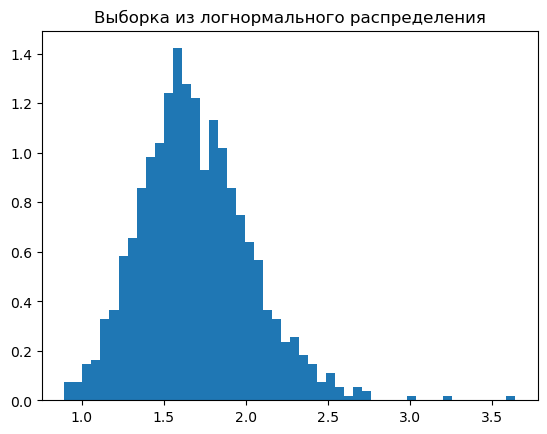

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры для исходного нормального распределения
mu = 0.5  # Среднее логарифмов
sigma = 0.2 # Стандартное отклонение логарифмов
size = 1000 # Количество точек для генерации

# Генерация логнормальной выборки
lognormal_sample = np.random.lognormal(mean=mu, sigma=sigma, size=size)

# Визуализация (опционально)
plt.hist(lognormal_sample, bins=50, density=True)
plt.title('Выборка из логнормального распределения')
plt.show()


In [118]:
import numpy as np
import pandas as pd
from scipy import stats

# Устанавливаем seed для воспроизводимости
np.random.seed(0)

# Параметры логнормального распределения
meanlog = 0.5
sdlog = 0.8
n = 50

# Генерация выборки из логнормального распределения
sample = np.random.lognormal(mean=meanlog, sigma=sdlog, size=n)

print(f"Размер выборки: n = {n}")
print(f"Выборочное среднее: {np.mean(sample):.4f}")
print(f"Выборочное стандартное отклонение: {np.std(sample, ddof=1):.4f}")

# a) Асимптотический 95% доверительный интервал (по ЦПТ)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
se = sample_std / np.sqrt(n)  # стандартная ошибка среднего
z_critical = stats.norm.ppf(0.975)  # 1.96 для 95% ДИ

ci_lower_clt = sample_mean - z_critical * se
ci_upper_clt = sample_mean + z_critical * se

print(f"\nа) Асимптотический 95% ДИ по ЦПТ:")
print(f"   Нижняя граница: {ci_lower_clt:.4f}")
print(f"   Верхняя граница: {ci_upper_clt:.4f}")

# b) Bootstrap percentile 95% доверительный интервал
B = 5000
bootstrap_means = np.zeros(B)

for i in range(B):
    # Генерируем bootstrap-выборку с повторениями
    bootstrap_sample = np.random.choice(sample, size=n, replace=True)
    bootstrap_means[i] = np.mean(bootstrap_sample)

# Находим 2.5% и 97.5% процентили
ci_lower_boot = np.percentile(bootstrap_means, 2.5)
ci_upper_boot = np.percentile(bootstrap_means, 97.5)

print(f"\nb) Bootstrap percentile 95% ДИ (B = {B}):")
print(f"   Нижняя граница: {ci_lower_boot:.4f}")
print(f"   Верхняя граница: {ci_upper_boot:.4f}")

# Ответ: нижняя граница bootstrap CI, округленная до 2 знаков после запятой
answer = round(ci_lower_boot, 2)
print(f"\nНижняя граница bootstrap CI (ответ): {answer}")

Размер выборки: n = 50
Выборочное среднее: 2.6907
Выборочное стандартное отклонение: 2.4216

а) Асимптотический 95% ДИ по ЦПТ:
   Нижняя граница: 2.0195
   Верхняя граница: 3.3619

b) Bootstrap percentile 95% ДИ (B = 5000):
   Нижняя граница: 2.0766
   Верхняя граница: 3.4000

Нижняя граница bootstrap CI (ответ): 2.08


## Функция Лапласа

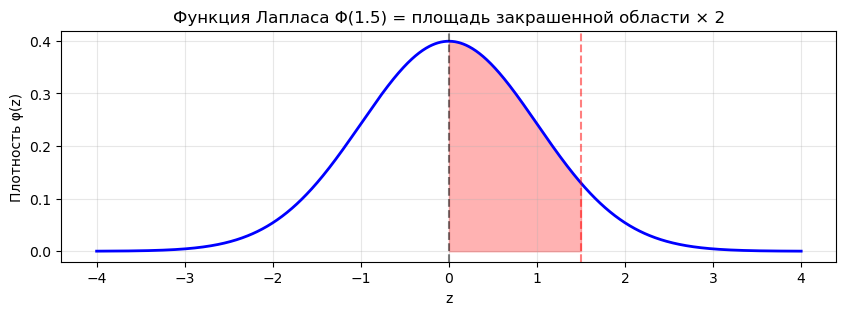

In [119]:
import numpy as np
import matplotlib.pyplot as plt

z = 1.5
x = np.linspace(-4, 4, 1000)
y = (1/np.sqrt(2*np.pi)) * np.exp(-x**2/2)

plt.figure(figsize=(10, 3))
plt.plot(x, y, 'b-', linewidth=2)

# Закрашиваем площадь от 0 до z
x_fill = np.linspace(0, z, 100)
y_fill = (1/np.sqrt(2*np.pi)) * np.exp(-x_fill**2/2)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='red')

plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=z, color='r', linestyle='--', alpha=0.5)
plt.title(f'Функция Лапласа Φ({z}) = площадь закрашенной области × 2')
plt.xlabel('z')
plt.ylabel('Плотность φ(z)')
plt.grid(True, alpha=0.3)
plt.show()

In [120]:
import numpy as np
from scipy import special, stats

# Способ 1: Через функцию распределения (чаще всего так)
def laplace_function_1(z):
    """"Простая" функция Лапласа (от 0 до z)"""
    return stats.norm.cdf(z) - 0.5

def laplace_function_2(z):
    """"Полная" функция Лапласа (с коэффициентом 2)"""
    return 2 * (stats.norm.cdf(z) - 0.5)

# Способ 2: Через специальные функции
def laplace_erf(z):
    """Через функцию ошибок"""
    return 0.5 * special.erf(z / np.sqrt(2))

# Пример вычисления
z = 1.96
print(f"z = {z}")
print(f"'Простая' Φ({z}) = {laplace_function_1(z):.6f}")
print(f"'Полная' Ф({z}) = {laplace_function_2(z):.6f}")
print(f"P(|Z| ≤ {z}) = {laplace_function_2(z):.6f}")
print(f"F({z}) = P(Z ≤ {z}) = {stats.norm.cdf(z):.6f}")

# Таблица значений
print("\nТаблица значений функции Лапласа:")
print("z\tФ(z)\tP(|Z|<z)")
for z_val in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    Ф_z = laplace_function_2(z_val)
    print(f"{z_val}\t{Ф_z:.4f}\t{Ф_z:.4f}")

z = 1.96
'Простая' Φ(1.96) = 0.475002
'Полная' Ф(1.96) = 0.950004
P(|Z| ≤ 1.96) = 0.950004
F(1.96) = P(Z ≤ 1.96) = 0.975002

Таблица значений функции Лапласа:
z	Ф(z)	P(|Z|<z)
0.5	0.3829	0.3829
1.0	0.6827	0.6827
1.5	0.8664	0.8664
2.0	0.9545	0.9545
2.5	0.9876	0.9876
3.0	0.9973	0.9973


# 3/15   Урок 3. Распределения, связанные с нормальным


## $\chi^2$ (хи-квадрат)

$\chi^2_k = \sum_{i=1}^k \xi_i^2$

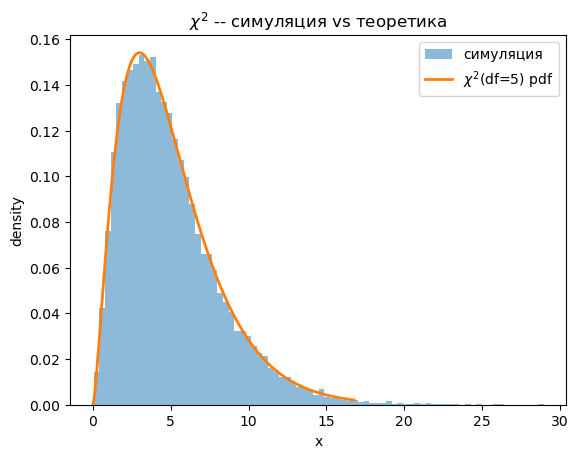

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(0)
k = 5
B = 20000
# симулируем сумму квадратов k стандартных нормалей
chis = np.sum(np.random.normal(size=(B, k))**2, axis=1)

# гистограмма и теоретическая плотность
xs = np.linspace(0, np.percentile(chis, 99.5), 500)
plt.hist(chis, bins=80, density=True, alpha=0.5, label='симуляция')
plt.plot(xs, chi2.pdf(xs, df=k), label=f'$\chi^2$(df={k}) pdf', lw=2)
plt.legend(); plt.xlabel('x'); plt.ylabel('density'); plt.title('$\chi^2$ -- симуляция vs теоретика')
plt.show()

In [122]:
chis

array([12.73930969,  2.05989432,  2.92665778, ...,  2.22894608,
        1.89700759,  7.77198711])

In [123]:
chis.shape

(20000,)

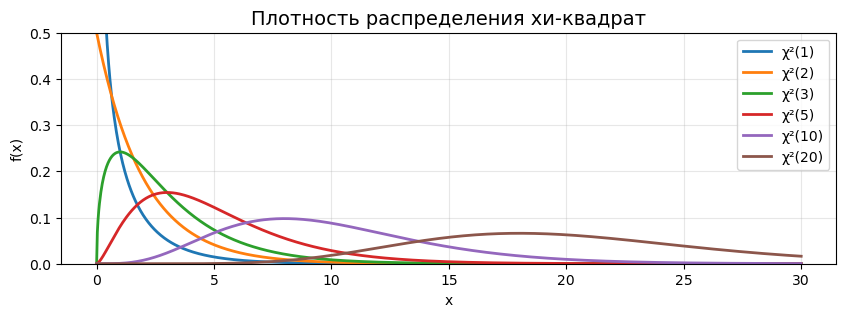

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Разные степени свободы
dfs = [1, 2, 3, 5, 10, 20]
x = np.linspace(0, 30, 1000)

plt.figure(figsize=(10, 3))
for k in dfs:
    plt.plot(x, stats.chi2.pdf(x, k), 
             label=f'χ²({k})', linewidth=2)

plt.title('Плотность распределения хи-квадрат', fontsize=14)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Распределение Стьюдента (t)


Распределение t возникает, когда мы берём нормированную ошибку среднего, но вместо истинного $\sigma$ используем оценку по данным. Эта дополнительная неопределённость делает хвосты распределения толще — ведь мы теперь учитываем, что и стандартное отклонение само подвержено случайности.

t-распределение незаменимо, когда $\sigma$ неизвестна, и именно оно лежит в основе t-интервалов и t-тестов — инструментов, с которыми мы постоянно сталкиваемся в анализе данных.

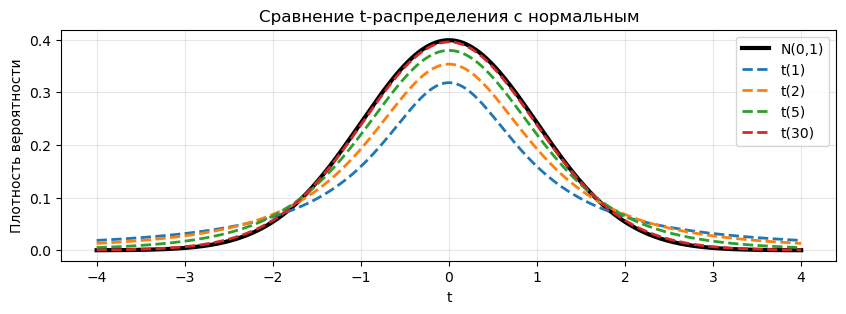

In [125]:
# Сравнение t-распределения с нормальным

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 3))

x = np.linspace(-4, 4, 1000)

# Нормальное распределение
ax.plot(x, stats.norm.pdf(x), 'k-', linewidth=3, label='N(0,1)')

# t-распределения с разными степенями свободы
for df in [1, 2, 5, 30]:
    ax.plot(x, stats.t.pdf(x, df), '--', linewidth=2, label=f't({df})')

ax.set_xlabel('t')
ax.set_ylabel('Плотность вероятности')
ax.set_title('Сравнение t-распределения с нормальным')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

$t_k = \frac{\xi_0}{\sqrt{\chi_k^2/k}}$

$t = \frac{\bar X - \mu}{s/\sqrt n} \sim t_{n-1}\quad\text{при }X_i\sim N(\mu,\sigma^2).$

На практике оно используется для t-тестов и t-интервалов для среднего при неизвестной $\sigma$. Толстые хвосты означают, что для небольших $n$ критические значения выше — тесты более консервативны.

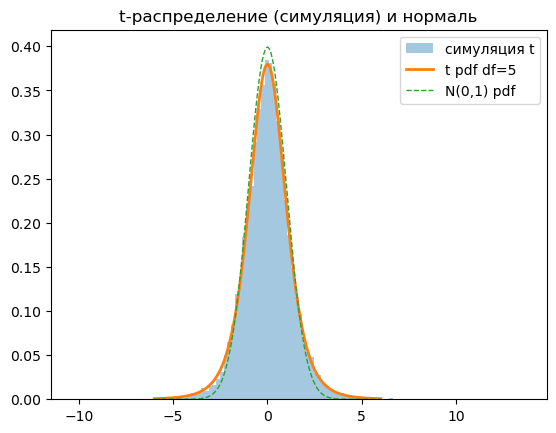

In [126]:
from scipy.stats import t, norm

np.random.seed(1)
df = 5
B = 20000
# симуляция t как ratio
z = np.random.normal(size=B)
chi = np.sum(np.random.normal(size=(B, df))**2, axis=1)
t_sim = z / np.sqrt(chi/df)

xs = np.linspace(-6, 6, 400)
plt.hist(t_sim, bins=120, density=True, alpha=0.4, label='симуляция t')
plt.plot(xs, t.pdf(xs, df), label=f't pdf df={df}', lw=2)
plt.plot(xs, norm.pdf(xs), label='N(0,1) pdf', lw=1, ls='--')
# plt.plot(figsize=(10, 3))
plt.legend(); plt.title('t-распределение (симуляция) и нормаль'); plt.show()

## Распределение Фишера (F)


In [127]:
from scipy.stats import f

np.random.seed(2)
n1, n2 = 30, 40
# симуляция нормальных выборок с разными дисперсиями
s1 = np.random.normal(loc=0, scale=1.2, size=n1)
s2 = np.random.normal(loc=0, scale=0.9, size=n2)

var1 = s1.var(ddof=1)
var2 = s2.var(ddof=1)
F_stat = var1 / var2
df1, df2 = n1-1, n2-1
p_upper = 1 - f.cdf(F_stat, df1, df2)
p_two_sided = 2 * min(p_upper, 1-p_upper)  # грубая двухсторонняя версия
print(f"F = {F_stat:.3f}, df1={df1}, df2={df2}, one-sided p = {p_upper:.4f}, approx two-sided p={p_two_sided:.4f}")

F = 1.625, df1=29, df2=39, one-sided p = 0.0782, approx two-sided p=0.1565


Важно помнить, что F-тест на равенство дисперсий очень чувствителен к отклонениям нормальности. При ненормальности лучше использовать робастные или непараметрические альтернативы (Levene, Brown-Forsythe для устойчивости к ненормальности).



## Задачи и упражнения


In [128]:
np.random.seed(19)
n1, n2 = 20, 40
# симуляция нормальных выборок с разными дисперсиями
s1 = np.random.normal(loc=0, scale=2, size=n1)
s2 = np.random.normal(loc=0, scale=3, size=n2)
np.var(s1), np.var(s1, ddof=1) 

(2.490246906650223, 2.621312533316024)

In [129]:
import numpy as np
np.random.seed(19)
sample = np.random.normal(0, 2, 20)
print(sample)
print(np.var(sample, ddof=0))
print(np.var(sample, ddof=1))

[ 4.42006525e-01 -6.80930018e-01 -1.15549708e+00 -8.08063110e-01
 -1.20657885e+00 -4.87704557e-01  2.07068748e+00  1.16150682e+00
  5.04827473e-01 -2.92509191e+00 -3.09668265e+00  5.30545457e-01
 -1.79241652e-03 -2.03198480e+00  2.23979213e-01 -2.38390410e+00
  3.11108780e+00 -1.86659984e+00  1.05306850e+00 -2.99929163e-01]
2.490246906650223
2.621312533316024


**Упражнение 5**


In [130]:
np.random.seed(251)
n1, n2 = 25, 30
# симуляция нормальных выборок с разными дисперсиями
s1 = np.random.normal(loc=0, scale=1.5, size=n1)
s2 = np.random.normal(loc=0, scale=1.0, size=n2)
ddof=1
np.var(s1, ddof=ddof), np.var(s2, ddof=ddof), np.var(s1, ddof=ddof) / np.var(s2, ddof=ddof),  

(2.9365462919857657, 1.4458154917589405, 2.031065726383414)

# 4/15   Урок 4. Преобразования нормальных выборок


In [131]:
import numpy as np
from scipy.stats import normaltest

np.random.seed(1)
X = np.random.normal(size=(1000, 2))  # 2D нормальные
A = np.array([[2, 1], [-1, 3]])       # произвольная матрица
Y = X @ A.T                           # линейное преобразование

print("Проверка нормальности компонент Y:")
for i in range(2):
    stat, p = normaltest(Y[:, i])
    print(f"  Компонента {i+1}: p-value = {p:.3f}")

Проверка нормальности компонент Y:
  Компонента 1: p-value = 0.382
  Компонента 2: p-value = 0.508


In [132]:
normaltest(X)

NormaltestResult(statistic=array([1.407929  , 0.90807178]), pvalue=array([0.49462049, 0.63505994]))

**Ортогональные преобразования сохраняют независимость**

In [133]:
from numpy.linalg import qr

n = 5
A = np.random.normal(size=(n, n))
Q, _ = qr(A)              # получаем ортогональную матрицу
X = np.random.normal(size=n)
Y = Q @ X

print("Среднее Y:", np.mean(Y).round(3))
print("Дисперсия Y:", np.var(Y, ddof=1).round(3))
print("Проверим ортогональность Q:", np.allclose(Q @ Q.T, np.eye(n)))

Среднее Y: -0.398
Дисперсия Y: 0.746
Проверим ортогональность Q: True


**Разложение на среднее и остатки**

In [134]:
from numpy.linalg import qr

n = 5
A = np.random.normal(size=(n, n))
Q, _ = qr(A)              # получаем ортогональную матрицу
X = np.random.normal(size=n)
Y = Q @ X

print("Среднее Y:", np.mean(Y).round(3))
print("Дисперсия Y:", np.var(Y, ddof=1).round(3))
print("Проверим ортогональность Q:", np.allclose(Q @ Q.T, np.eye(n)))
print("CDF χ²:", chi2.cdf(Y, df=n-1))

Среднее Y: 0.032
Дисперсия Y: 0.682
Проверим ортогональность Q: True
CDF χ²: [0.05579828 0.         0.05798794 0.         0.00269625]


**Проекции и матричная форма**

In [135]:
n = 5
X = np.random.normal(0, 1, n)
P = np.ones((n, n)) / n
proj = P @ X
resid = X - proj

print("X:", X.round(2))
print("Проекция на среднее:", proj.round(2))
print("Остатки:", resid.round(2))
print("Проверка ортогональности:", np.isclose(np.dot(proj, resid), 0))

X: [-1.61  0.72  0.92  0.91 -0.33]
Проекция на среднее: [0.12 0.12 0.12 0.12 0.12]
Остатки: [-1.73  0.6   0.8   0.79 -0.45]
Проверка ортогональности: True


## Упражнения

In [136]:
import numpy as np
from scipy import stats

# Параметры
n = 15
seed = 12  # можно изменить на любой другой
mu0 = 0

# Генерация выборки
np.random.seed(seed)
sample = np.random.randn(n)

# Вычисление выборочных характеристик
x_bar = np.mean(sample)
s = np.std(sample, ddof=1)  # несмещенное стандартное отклонение

# t-статистика
t_stat = (x_bar - mu0) / (s / np.sqrt(n))
t_squared = t_stat ** 2

print(f"Выборка: {sample.round(3)}")
print(f"Среднее: {x_bar:.3f}")
print(f"Стандартное отклонение: {s:.3f}")
print(f"t-статистика: {t_stat:.3f}")
print(f"t^2: {t_squared:.3f}")
print(f"t^2 (округлено до двух знаков): {t_squared:.2f}")

Выборка: [ 0.473 -0.681  0.242 -1.701  0.753 -1.535  0.005 -0.12  -0.807  2.872
 -0.598  0.472  1.096 -1.215  1.342]
Среднее: 0.040
Стандартное отклонение: 1.210
t-статистика: 0.128
t^2: 0.016
t^2 (округлено до двух знаков): 0.02


In [137]:
n = 20
np.random.seed(1)
X = np.random.normal(0, 1, n)
P = np.ones((n, n)) / n
proj = P @ X
resid = X - proj

print("X:", X.round(2))
print("Проекция на среднее:", proj.round(2))
print("Остатки:", resid.round(2))
print("Проверка ортогональности:", np.isclose(np.dot(proj, resid), 0))

X: [ 1.62 -0.61 -0.53 -1.07  0.87 -2.3   1.74 -0.76  0.32 -0.25  1.46 -2.06
 -0.32 -0.38  1.13 -1.1  -0.17 -0.88  0.04  0.58]
Проекция на среднее: [-0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13
 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13 -0.13]
Остатки: [ 1.76 -0.48 -0.39 -0.94  1.   -2.17  1.88 -0.63  0.45 -0.12  1.6  -1.93
 -0.19 -0.25  1.27 -0.97 -0.04 -0.74  0.18  0.72]
Проверка ортогональности: True


In [138]:
import numpy as np

# Параметры
n = 20
seed = 1

# Генерация выборки
np.random.seed(seed)
X = np.random.randn(n)

# Вычисление среднего
X_bar = np.mean(X)

# Способ 1: Сумма квадратов отклонений от среднего
sum_sq_dev = np.sum((X - X_bar)**2)

# Способ 2: Квадратичная форма X^T(I-P)X
# Создаем вектор из единиц
ones = np.ones(n)
# Матрица P = (1/n) * 11^T
P = (1/n) * np.outer(ones, ones)
# Матрица I - P
I_minus_P = np.eye(n) - P
# Вычисляем X^T(I-P)X
quadratic_form = X.T @ I_minus_P @ X  # или np.dot(X.T, np.dot(I_minus_P, X))

# Разница по модулю
difference = abs(sum_sq_dev - quadratic_form)

# Результаты
print(f"Выборка X: {X}")
print(f"\nСреднее X̄: {X_bar:.4f}")
print(f"\n1. Σ(Xᵢ - X̄)² = {sum_sq_dev:.8f}")
print(f"2. Xᵀ(I-P)X = {quadratic_form:.8f}")
print(f"\nРазница по модулю |1 - 2| = {difference:.8f}")
print(f"Округлено до 4 знаков: {difference:.4f}")

# Проверка: вычисление суммы квадратов отклонений другим способом
# sum_sq_dev_alt = np.sum(X**2) - n * X_bar**2
# print(f"\nАльтернативный расчет Σ(Xᵢ - X̄)² = {sum_sq_dev_alt:.8f}")

Выборка X: [ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387
  1.74481176 -0.7612069   0.3190391  -0.24937038  1.46210794 -2.06014071
 -0.3224172  -0.38405435  1.13376944 -1.09989127 -0.17242821 -0.87785842
  0.04221375  0.58281521]

Среднее X̄: -0.1334

1. Σ(Xᵢ - X̄)² = 24.19144099
2. Xᵀ(I-P)X = 24.19144099

Разница по модулю |1 - 2| = 0.00000000
Округлено до 4 знаков: 0.0000


# 5/15   Урок 5. Доверительные интервалы для параметров нормального распределения


Рассмотрим на Python симуляцию покрытия t-интервала


In [139]:
import numpy as np
from scipy.stats import t, norm

def empirical_coverage_t(mu=0, sigma=1, n=10, alpha=0.05, B=5000, seed=0):
    rng = np.random.default_rng(seed)
    contains = 0
    for _ in range(B):
        x = rng.normal(loc=mu, scale=sigma, size=n)
        xbar = x.mean()
        s = x.std(ddof=1)
        t_q = t.ppf(1-alpha/2, df=n-1)
        lo = xbar - t_q * s / np.sqrt(n)
        hi = xbar + t_q * s / np.sqrt(n)
        if lo <= mu <= hi:
            contains += 1
    return contains / B

print("Empirical coverage (n=10):", empirical_coverage_t(n=10))
print("Empirical coverage (n=30):", empirical_coverage_t(n=30))

Empirical coverage (n=10): 0.9488
Empirical coverage (n=30): 0.9458


**Примеры на Python**

Сгенерируем выборку и рассмотрим сквозные примеры применения всех изученных методов на Python:

In [140]:
import numpy as np
from scipy.stats import norm, t, chi2, f

np.random.seed(42)

# Параметры
n = 20
mu_true = 2.5
sigma_true = 1.7
alpha = 0.05

# сгенерируем выборку
x = np.random.normal(loc=mu_true, scale=sigma_true, size=n)
xbar = x.mean()
s = x.std(ddof=1)

# 1) z-interval (если sigma известно)
zq = norm.ppf(1-alpha/2)
ci_z = (xbar - zq * sigma_true/np.sqrt(n), xbar + zq * sigma_true/np.sqrt(n))
print("z-CI (sigma known):", ci_z)

# 2) t-interval (sigma unknown)
tq = t.ppf(1-alpha/2, df=n-1)
ci_t = (xbar - tq * s/np.sqrt(n), xbar + tq * s/np.sqrt(n))
print("t-CI (sigma unknown):", ci_t)

# 3) CI for sigma^2 via chi2
chi_low = chi2.ppf(alpha/2, df=n-1)
chi_high = chi2.ppf(1-alpha/2, df=n-1)
ci_var = ((n-1)*s*s/chi_high, (n-1)*s*s/chi_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print("CI for sigma^2:", ci_var)
print("CI for sigma:", ci_sigma)

# 4) Prediction interval for a single future observation
pred_halfwidth = tq * s * np.sqrt(1 + 1/n)
pred_interval = (xbar - pred_halfwidth, xbar + pred_halfwidth)
print("Prediction interval for next obs:", pred_interval)

z-CI (sigma known): (1.4637482860587958, 2.953836605038984)
t-CI (sigma unknown): (1.4449703214786414, 2.9726145696191386)
CI for sigma^2: (1.5404708668001819, 5.682137628043295)
CI for sigma: (1.2411570677396886, 2.3837234797776556)
Prediction interval for next obs: (-1.2914802554849762, 5.709065146582756)


## Упражнения

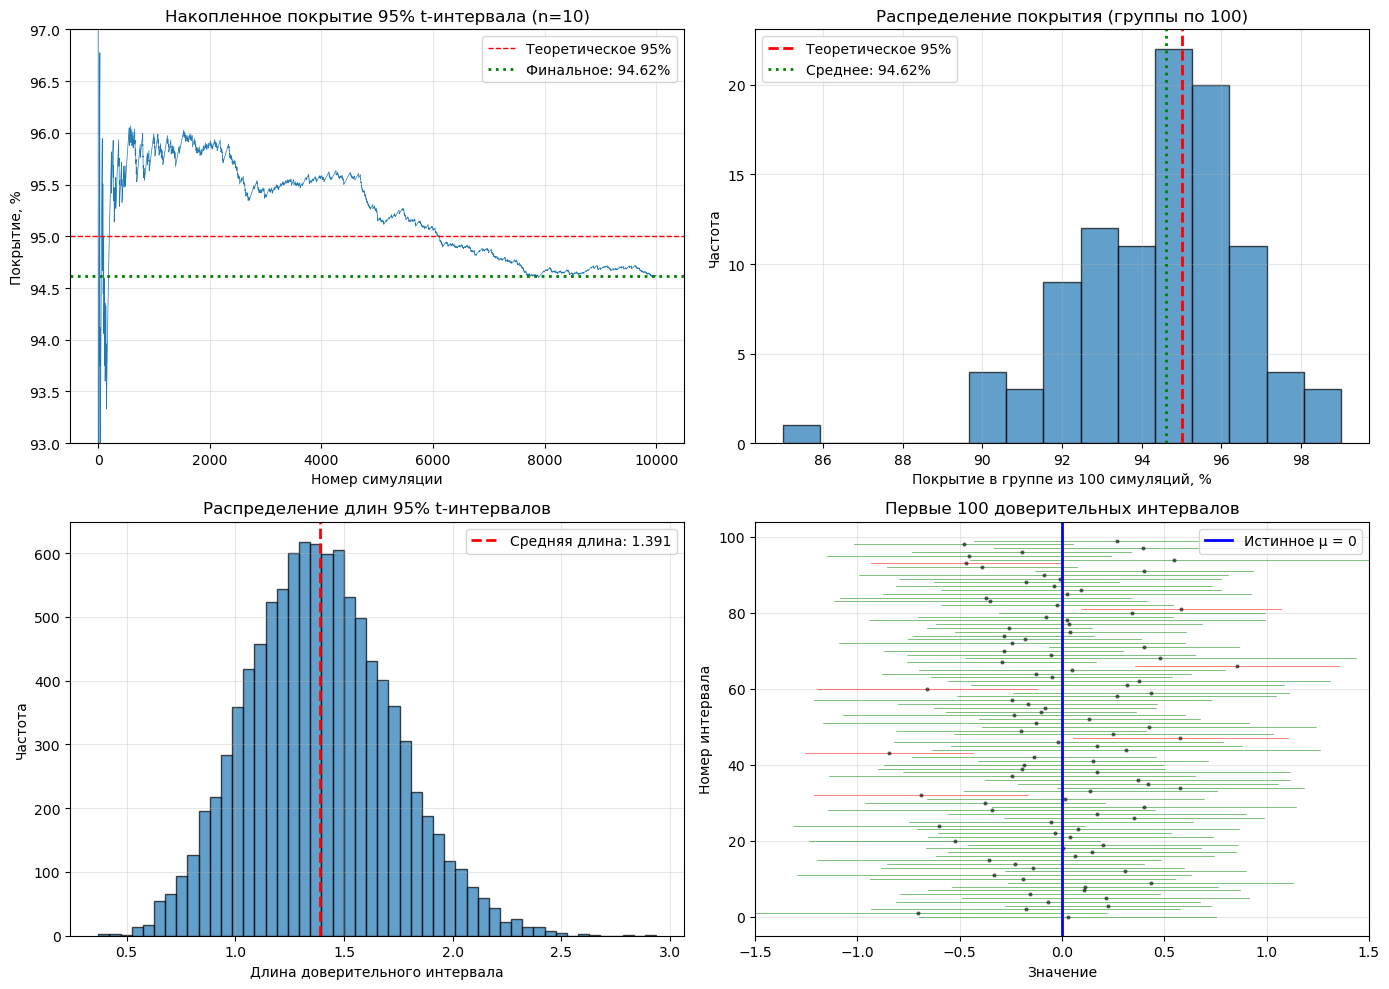

=== Результаты симуляции (n=10, 10000 повторений) ===
Теоретическое покрытие: 95.00%
Эмпирическое покрытие: 94.6200%
Отклонение от теоретического: 0.3800%
Средняя длина интервала: 1.3906
Стандартное отклонение длины: 0.3306
Минимальная длина: 0.3693
Максимальная длина: 2.9360
Доля интервалов, не покрывающих μ: 5.3800%

95% ДИ для истинного покрытия: [94.18%, 95.06%]
✓ 95% находится внутри ДИ для покрытия (статистически не отличается от 95%)


In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Параметры
n = 10  # размер выборки
mu = 0  # истинное среднее (можно изменить на любое другое значение)
sigma = 1  # истинное стандартное отклонение
alpha = 0.05  # уровень значимости
confidence_level = 1 - alpha  # 95%
n_simulations = 10000  # количество симуляций

np.random.seed(42)  # для воспроизводимости

# Храним результаты
coverages = []
ci_lengths = []

# Монте-Карло симуляция
for i in range(n_simulations):
    # Генерируем выборку из N(mu, sigma^2)
    sample = np.random.normal(mu, sigma, n)
    
    # Вычисляем выборочные характеристики
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)  # несмещенная оценка
    
    # Стандартная ошибка среднего
    se = sample_std / np.sqrt(n)
    
    # t-критическое значение
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    
    # Доверительный интервал
    ci_lower = sample_mean - t_critical * se
    ci_upper = sample_mean + t_critical * se
    ci_length = ci_upper - ci_lower
    
    # Проверяем, покрывает ли интервал истинное значение mu
    covers = (ci_lower <= mu <= ci_upper)
    
    coverages.append(covers)
    ci_lengths.append(ci_length)

# Преобразуем в numpy array для удобства
coverages = np.array(coverages)
ci_lengths = np.array(ci_lengths)

# Вычисляем эмпирическое покрытие
empirical_coverage = np.mean(coverages) * 100

# Визуализация 1: Накопленное покрытие
cumulative_coverage = np.cumsum(coverages) / (np.arange(1, n_simulations + 1)) * 100

plt.figure(figsize=(14, 10))

# График 1: Накопленное покрытие
plt.subplot(2, 2, 1)
plt.plot(range(1, n_simulations + 1), cumulative_coverage, linewidth=0.5)
plt.axhline(y=95, color='r', linestyle='--', linewidth=1, label='Теоретическое 95%')
plt.axhline(y=empirical_coverage, color='g', linestyle=':', linewidth=2, 
           label=f'Финальное: {empirical_coverage:.2f}%')
plt.xlabel('Номер симуляции')
plt.ylabel('Покрытие, %')
plt.title(f'Накопленное покрытие 95% t-интервала (n={n})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(93, 97)

# График 2: Гистограмма покрытий (бинами по 100 симуляций)
plt.subplot(2, 2, 2)
# Разбиваем на группы по 100 симуляций
group_size = 100
n_groups = n_simulations // group_size
group_coverages = []

for i in range(n_groups):
    group = coverages[i*group_size:(i+1)*group_size]
    group_coverages.append(np.mean(group) * 100)

plt.hist(group_coverages, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(x=95, color='r', linestyle='--', linewidth=2, label='Теоретическое 95%')
plt.axvline(x=np.mean(group_coverages), color='g', linestyle=':', linewidth=2,
           label=f'Среднее: {np.mean(group_coverages):.2f}%')
plt.xlabel('Покрытие в группе из 100 симуляций, %')
plt.ylabel('Частота')
plt.title(f'Распределение покрытия (группы по {group_size})')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Распределение длин доверительных интервалов
plt.subplot(2, 2, 3)
plt.hist(ci_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=np.mean(ci_lengths), color='r', linestyle='--', linewidth=2,
           label=f'Средняя длина: {np.mean(ci_lengths):.3f}')
plt.xlabel('Длина доверительного интервала')
plt.ylabel('Частота')
plt.title('Распределение длин 95% t-интервалов')
plt.legend()
plt.grid(True, alpha=0.3)

# График 4: Визуализация нескольких интервалов
plt.subplot(2, 2, 4)
n_intervals_to_show = 100

# Выбираем первые n_intervals_to_show интервалов
for i in range(min(n_intervals_to_show, n_simulations)):
    # Вычисляем интервал (повторяем вычисления или сохраняем заранее)
    sample = np.random.normal(mu, sigma, n)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    se = sample_std / np.sqrt(n)
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_lower = sample_mean - t_critical * se
    ci_upper = sample_mean + t_critical * se
    
    # Цвет в зависимости от покрытия
    color = 'green' if (ci_lower <= mu <= ci_upper) else 'red'
    
    # Рисуем интервал
    plt.plot([ci_lower, ci_upper], [i, i], color=color, linewidth=0.5, alpha=0.7)
    plt.plot(sample_mean, i, 'o', markersize=2, color='black', alpha=0.5)

plt.axvline(x=mu, color='blue', linestyle='-', linewidth=2, label=f'Истинное μ = {mu}')
plt.xlabel('Значение')
plt.ylabel('Номер интервала')
plt.title(f'Первые {n_intervals_to_show} доверительных интервалов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(mu - 1.5*sigma, mu + 1.5*sigma)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print(f"=== Результаты симуляции (n={n}, {n_simulations} повторений) ===")
print(f"Теоретическое покрытие: 95.00%")
print(f"Эмпирическое покрытие: {empirical_coverage:.4f}%")
print(f"Отклонение от теоретического: {abs(empirical_coverage - 95):.4f}%")
print(f"Средняя длина интервала: {np.mean(ci_lengths):.4f}")
print(f"Стандартное отклонение длины: {np.std(ci_lengths):.4f}")
print(f"Минимальная длина: {np.min(ci_lengths):.4f}")
print(f"Максимальная длина: {np.max(ci_lengths):.4f}")
print(f"Доля интервалов, не покрывающих μ: {(1 - empirical_coverage/100):.4%}")

# Доверительный интервал для оценки покрытия
# Стандартная ошибка пропорции
se_prop = np.sqrt((empirical_coverage/100 * (1 - empirical_coverage/100)) / n_simulations)
ci_lower_prop = (empirical_coverage/100 - 1.96*se_prop) * 100
ci_upper_prop = (empirical_coverage/100 + 1.96*se_prop) * 100
print(f"\n95% ДИ для истинного покрытия: [{ci_lower_prop:.2f}%, {ci_upper_prop:.2f}%]")

# Проверка: покрывает ли ДИ теоретическое значение 95%?
if ci_lower_prop <= 95 <= ci_upper_prop:
    print("✓ 95% находится внутри ДИ для покрытия (статистически не отличается от 95%)")
else:
    print("✗ 95% НЕ находится внутри ДИ для покрытия (статистически отличается от 95%)")

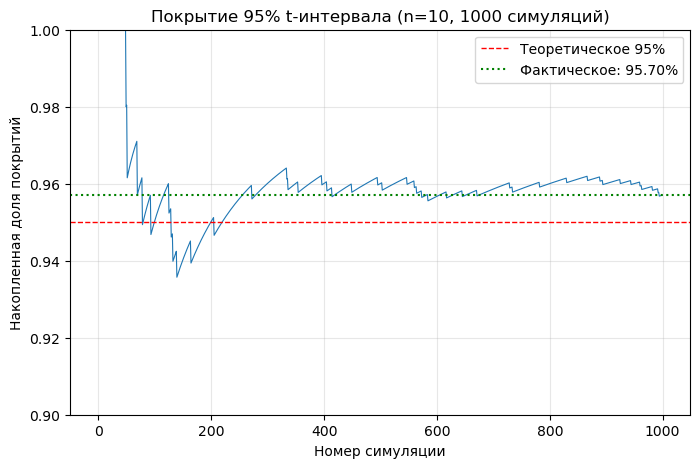

Итоговое покрытие: 95.70% (957/1000)


In [142]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Параметры
n = 10
mu = 0
n_sim = 1000

# Симуляция
covers = []
for _ in range(n_sim):
    sample = np.random.randn(n)
    mean = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n)
    t = stats.t.ppf(0.975, n-1)
    ci_low = mean - t * se
    ci_high = mean + t * se
    covers.append(ci_low <= mu <= ci_high)

# График
cumulative = np.cumsum(covers) / (np.arange(n_sim) + 1)
plt.figure(figsize=(8, 5))
plt.plot(cumulative, linewidth=0.8)
plt.axhline(0.95, color='red', linestyle='--', linewidth=1, label='Теоретическое 95%')
plt.axhline(np.mean(covers), color='green', linestyle=':', linewidth=1.5, 
           label=f'Фактическое: {np.mean(covers):.2%}')
plt.xlabel('Номер симуляции')
plt.ylabel('Накопленная доля покрытий')
plt.title(f'Покрытие 95% t-интервала (n={n}, {n_sim} симуляций)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.9, 1)
plt.show()

print(f'Итоговое покрытие: {np.mean(covers):.2%} ({np.sum(covers)}/{n_sim})')

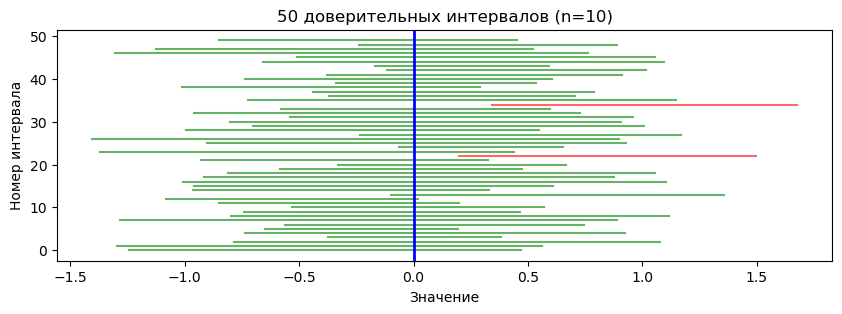

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n, mu, sims = 10, 0, 50
plt.figure(figsize=(10, 3))
for i in range(sims):
    x = np.random.randn(n)
    ci = np.mean(x) + np.array([-1,1])*stats.t.ppf(0.975,n-1)*np.std(x,ddof=1)/np.sqrt(n)
    plt.plot(ci, [i,i], 'r' if mu<ci[0] or mu>ci[1] else 'g', alpha=0.6)
plt.axvline(mu, c='b', lw=2)
plt.title(f'{sims} доверительных интервалов (n={n})')
plt.xlabel('Значение')
plt.ylabel('Номер интервала')
plt.show()

In [144]:
import numpy as np
from scipy import stats

# Данные
data = np.array([23, 25, 28, 22, 27, 24, 26, 29, 30, 21])
n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1)
alpha = 0.05

# Двусторонний 95% ДИ
t_crit_two = stats.t.ppf(1 - alpha/2, df=n-1)
ci_two = (mean - t_crit_two * std/np.sqrt(n), 
          mean + t_crit_two * std/np.sqrt(n))

# Односторонний 95% ДИ (правосторонний)
t_crit_one = stats.t.ppf(1 - alpha, df=n-1)
ci_one = (mean - t_crit_one * std/np.sqrt(n), np.inf)

print(f"Двусторонний 95% ДИ: [{ci_two[0]:.2f}, {ci_two[1]:.2f}]")
print(f"Односторонний 95% ДИ (правосторонний): [{ci_one[0]:.2f}, ∞)")

Двусторонний 95% ДИ: [23.33, 27.67]
Односторонний 95% ДИ (правосторонний): [23.74, ∞)


In [145]:
import matplotlib.pyplot as plt

def plot_confidence_intervals(data, true_mean=None):
    """Визуализация односторонних и двусторонних ДИ"""
    n = len(data)
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)
    
    # Критические значения
    t_crit_two = stats.t.ppf(0.975, df=n-1)
    t_crit_one = stats.t.ppf(0.95, df=n-1)
    
    # Интервалы
    ci_two = (mean_val - t_crit_two * std_val/np.sqrt(n),
              mean_val + t_crit_two * std_val/np.sqrt(n))
    ci_one_lower = mean_val - t_crit_one * std_val/np.sqrt(n)
    ci_one_upper = mean_val + t_crit_one * std_val/np.sqrt(n)
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Двусторонний ДИ
    ax.errorbar(1, mean_val, yerr=[[mean_val - ci_two[0]], [ci_two[1] - mean_val]], 
                fmt='o', capsize=10, label='Двусторонний 95% ДИ', color='blue')
    
    # Односторонние ДИ
    ax.errorbar(2, mean_val, yerr=[[mean_val - ci_one_lower], [0]], 
                fmt='o', capsize=10, label='Односторонний (≥) 95% ДИ', color='green')
    ax.errorbar(3, mean_val, yerr=[[0], [ci_one_upper - mean_val]], 
                fmt='o', capsize=10, label='Односторонний (≤) 95% ДИ', color='red')
    
    if true_mean is not None:
        ax.axhline(y=true_mean, color='k', linestyle='--', alpha=0.5, label='Истинное значение')
    
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Двусторонний', 'Односторонний (≥)', 'Односторонний (≤)'])
    ax.set_ylabel('Значение')
    ax.set_title('Сравнение доверительных интервалов')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
    
    return ci_two, ci_one_lower, ci_one_upper

Упражнение 4.1
0 points possible (ungraded)
Сгенерируйте две независимые выборки:
и
з
и
з
(seed = 42). Постройте 95% доверительный интервал для разности сред  по формуле Уэлча. Введите нижнюю границу интервала, округлив до двух знаков.

In [146]:
import numpy as np
from scipy import stats

# Установка seed
np.random.seed(42)

# Параметры распределений
mu1, sigma1 = 2, 1
n1 = 12
mu2, sigma2 = 2.5, 1.3
n2 = 18

# Генерация выборок
sample1 = np.random.normal(mu1, sigma1, n1)
sample2 = np.random.normal(mu2, sigma2, n2)

# Выборочные характеристики
x1_bar = np.mean(sample1)
s1_sq = np.var(sample1, ddof=1)  # исправленная выборочная дисперсия
x2_bar = np.mean(sample2)
s2_sq = np.var(sample2, ddof=1)

# Стандартная ошибка разности средних (Уэлч)
se = np.sqrt(s1_sq / n1 + s2_sq / n2)

# Разность выборочных средних
diff = x1_bar - x2_bar

# Степени свободы по формуле Уэлча-Саттертуэйта
df = (s1_sq / n1 + s2_sq / n2) ** 2 / \
     ((s1_sq / n1) ** 2 / (n1 - 1) + (s2_sq / n2) ** 2 / (n2 - 1))

# Критическое значение t-распределения (двусторонний 95% ДИ)
t_crit = stats.t.ppf(0.975, df)

# Доверительный интервал
lower_bound = diff - t_crit * se
upper_bound = diff + t_crit * se

# Округление до двух знаков
lower_bound_rounded = round(lower_bound, 2)
upper_bound_rounded = round(upper_bound, 2)

print(f"Выборочное среднее 1: {x1_bar:.4f}")
print(f"Выборочная дисперсия 1: {s1_sq:.4f}")
print(f"Выборочное среднее 2: {x2_bar:.4f}")
print(f"Выборочная дисперсия 2: {s2_sq:.4f}")
print(f"Разность средних: {diff:.4f}")
print(f"Стандартная ошибка: {se:.4f}")
print(f"Степени свободы: {df:.2f}")
print(f"Критическое t-значение: {t_crit:.4f}")
print(f"95% ДИ Уэлча: ({lower_bound:.4f}, {upper_bound:.4f})")
print(f"Нижняя граница (округлено): {lower_bound_rounded}")
print(f"Верхняя граница (округлено): {upper_bound_rounded}")

Выборочное среднее 1: 2.2960
Выборочная дисперсия 1: 0.5539
Выборочное среднее 2: 1.8359
Выборочная дисперсия 2: 1.2636
Разность средних: 0.4601
Стандартная ошибка: 0.3411
Степени свободы: 28.00
Критическое t-значение: 2.0484
95% ДИ Уэлча: (-0.2386, 1.1588)
Нижняя граница (округлено): -0.24
Верхняя граница (округлено): 1.16


In [147]:
import numpy as np
from scipy import stats

# Установка seed для воспроизводимости
np.random.seed(42)

# Параметры распределений
mu1, sigma1 = 2, 1
n1 = 12
mu2, sigma2 = 2.5, 1.3
n2 = 18

# Генерация выборок
sample1 = np.random.normal(mu1, sigma1, n1)
sample2 = np.random.normal(mu2, sigma2, n2)

# Выборочные дисперсии (исправленные)
s1_sq = np.var(sample1, ddof=1)
s2_sq = np.var(sample2, ddof=1)

# Отношение выборочных дисперсий
ratio = s1_sq / s2_sq

# Квантили F-распределения
# Для 95% доверительного интервала: α=0.05, α/2=0.025
# F_{α/2, n1-1, n2-1} и F_{1-α/2, n1-1, n2-1}
F_lower = stats.f.ppf(0.025, n1-1, n2-1)  # F_{0.025, 11, 17}
F_upper = stats.f.ppf(0.975, n1-1, n2-1)  # F_{0.975, 11, 17}

# Доверительный интервал для отношения дисперсий σ1²/σ2²
lower_bound = ratio / F_upper
upper_bound = ratio / F_lower

# Округление до двух знаков
lower_bound_rounded = round(lower_bound, 2)
upper_bound_rounded = round(upper_bound, 2)

print(f"Выборочная дисперсия 1 (s1²): {s1_sq:.4f}")
print(f"Выборочная дисперсия 2 (s2²): {s2_sq:.4f}")
print(f"Отношение дисперсий (s1²/s2²): {ratio:.4f}")
print(f"F-квантили: F_{{0.025,11,17}} = {F_lower:.4f}, F_{{0.975,11,17}} = {F_upper:.4f}")
print(f"95% ДИ для σ1²/σ2²: ({lower_bound:.4f}, {upper_bound:.4f})")
print(f"Нижняя граница (округлено): {lower_bound_rounded}")
print(f"Верхняя граница (округлено): {upper_bound_rounded}")

Выборочная дисперсия 1 (s1²): 0.5539
Выборочная дисперсия 2 (s2²): 1.2636
Отношение дисперсий (s1²/s2²): 0.4384
F-квантили: F_{0.025,11,17} = 0.3047, F_{0.975,11,17} = 2.8696
95% ДИ для σ1²/σ2²: (0.1528, 1.4385)
Нижняя граница (округлено): 0.15
Верхняя граница (округлено): 1.44


# 6/15   Урок 6. Асимптотический доверительный интервал


Практика на Python

Ниже приведены функции для расчёта CI и проверки покрытия:

* Вычисление асимптотического доверительного интервала (CI) для параметра  — для экспоненциального и пуассоновского распределений.
* Симуляция покрытия интервала, чтобы проверить, насколько часто он действительно содержит истинное значение параметра.

In [148]:
import numpy as np
from scipy.stats import norm
np.random.seed(0)

z95 = norm.ppf(0.975)

def exp_lambda_ci(data, alpha=0.05):
    n = len(data)
    hat_lambda = 1.0/np.mean(data)
    se = hat_lambda/np.sqrt(n)   # plug-in SE via delta method
    lo = hat_lambda - norm.ppf(1-alpha/2)*se
    hi = hat_lambda + norm.ppf(1-alpha/2)*se
    return hat_lambda, lo, hi

def pois_lambda_ci(data, alpha=0.05):
    n = len(data)
    hat_lambda = np.mean(data)
    se = np.sqrt(hat_lambda/n)
    lo = hat_lambda - norm.ppf(1-alpha/2)*se
    hi = hat_lambda + norm.ppf(1-alpha/2)*se
    return hat_lambda, lo, hi

При больших $n$ эмпирическое покрытие ≈ заявленное $1-\alpha$; при малых $n$ (особенно для скошенных распределений) возможны отклонения.

Практические рекомендации (чек-лист):

Проверьте размер выборки и форму распределения (гистограмма, QQ-plot).
Сравните интервал с бутстрэп-результатом.
Используйте корректную формулу для SE (дельта-метод, информация Фишера и т.д.).
Для параметров у границ (долей 0 или 1) используйте Wilson, Clopper–Pearson и др.
При сомнениях — проведите симуляцию покрытия для своей модели и $n$.

## Упражнения

**Упражнение 4**

Сгенерируйте $n=40$ наблюдений $X_i \sim \mathrm{Exp}(\lambda=1.5)$, seed=0. Постройте bootstrap percentile CI для $\lambda$ с $B=5000$. Введите нижнюю границу CI, округлив до 1 знака.

In [149]:
import numpy as np

# Параметры
np.random.seed(0)  # seed = 0
n = 40
lambda_true = 1.5
B = 5000

# 1. Генерация исходной выборки из Exp(lambda = 1.5)
data = np.random.exponential(scale=1/lambda_true, size=n)  # scale = 1/λ

# 2. Оценка λ по исходной выборке: hatλ = 1 / X̄
lambda_hat = 1 / np.mean(data)

# 3. Бутстрэп
bootstrap_lambdas = np.zeros(B)
for i in range(B):
    bootstrap_sample = np.random.choice(data, size=n, replace=True)
    bootstrap_lambdas[i] = 1 / np.mean(bootstrap_sample)

# 4. Percentile CI (2.5% и 97.5%)
ci_lower = np.percentile(bootstrap_lambdas, 2.5)
ci_upper = np.percentile(bootstrap_lambdas, 97.5)

# 5. Округление до 1 знака после запятой
ci_lower_rounded = round(ci_lower, 1)
ci_upper_rounded = round(ci_upper, 1)

print(f"Оценка λ: {lambda_hat:.3f}")
print(f"Бутстрэп CI (процентильный): [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"Нижняя граница (округлено до 1 знака): {ci_lower_rounded}")
print(f"Верхняя граница (округлено до 1 знака): {ci_upper_rounded}")

Оценка λ: 1.292
Бутстрэп CI (процентильный): [1.026, 1.661]
Нижняя граница (округлено до 1 знака): 1.0
Верхняя граница (округлено до 1 знака): 1.7


In [150]:
import numpy as np

# Параметры
np.random.seed(0)
lambda1_true = 2
lambda2_true = 3
n1 = 25
n2 = 30

# 1. Генерация независимых выборок
data1 = np.random.exponential(scale=1/lambda1_true, size=n1)  # scale = 1/λ
data2 = np.random.exponential(scale=1/lambda2_true, size=n2)

# 2. Точечные оценки λ1 и λ2
lambda1_hat = 1 / np.mean(data1)
lambda2_hat = 1 / np.mean(data2)

# 3. Оценка θ = λ1 / λ2
theta_hat = lambda1_hat / lambda2_hat

# 4. Стандартная ошибка оценки θ (дельта-метод)
# Asymptotic SE = (λ1/λ2) * sqrt(1/n1 + 1/n2)
se_theta = theta_hat * np.sqrt(1/n1 + 1/n2)

# 5. Асимптотический 95% ДИ: θ_hat ± z_{0.975} * SE
z = 1.96  # квантиль для 95% ДИ
ci_lower = theta_hat - z * se_theta
ci_upper = theta_hat + z * se_theta

# 6. Округление верхней границы до 2 знаков после запятой
ci_upper_rounded = round(ci_upper, 2)

print(f"Оценка λ1: {lambda1_hat:.4f}")
print(f"Оценка λ2: {lambda2_hat:.4f}")
print(f"Оценка θ = λ1/λ2: {theta_hat:.4f}")
print(f"Стандартная ошибка оценки θ: {se_theta:.4f}")
print(f"Асимптотический 95% ДИ для θ: [{ci_lower:.4f}, {ci_upper:.4f}]")

Оценка λ1: 1.6161
Оценка λ2: 3.2835
Оценка θ = λ1/λ2: 0.4922
Стандартная ошибка оценки θ: 0.1333
Асимптотический 95% ДИ для θ: [0.2310, 0.7534]


# 7/15   Урок 7. Проверка гипотез


## Примеры на Python

### Симуляция ошибок I/II рода и мощности

In [163]:
import numpy as np
from scipy.stats import norm

def z_test_reject(x, mu0=0.0, sigma=1.0, alpha=0.05):
    n = len(x)
    z = (x.mean() - mu0) / (sigma/np.sqrt(n))
    crit = norm.ppf(1-alpha/2)
    return abs(z) > crit

def estimate_power(mu0=0.0, mu1=0.3, sigma=1.0, n=50, alpha=0.05, B=2000, seed=1):
    rng = np.random.default_rng(seed)
    rejects = 0
    for _ in range(B):
        x = rng.normal(loc=mu1, scale=sigma, size=n)
        if z_test_reject(x, mu0=mu0, sigma=sigma, alpha=alpha):
            rejects += 1
    return rejects / B

estimate_power(mu1=0.5, n=1000)

1.0

### t-test (scipy) и сравнение с permutation test

не работает

In [152]:
import numpy as np
from scipy.stats import norm

def z_test_reject(x, mu0=0.0, sigma=1.0, alpha=0.05):
    n = len(x)
    z = (x.mean() - mu0) / (sigma/np.sqrt(n))
    crit = norm.ppf(1-alpha/2)
    return abs(z) > crit

def estimate_power(mu0=0.0, mu1=0.3, sigma=1.0, n=50, alpha=0.05, B=2000, seed=1):
    rng = np.random.default_rng(seed)
    rejects = 0
    for _ in range(B):
        x = rng.normal(loc=mu1, scale=sigma, size=n)
        if z_test_reject(x, mu0=mu0, sigma=sigma, alpha=alpha):
            rejects += 1
    return rejects / B

print("Estimated power (mu1=0.3, n=50):", estimate_power(mu1=0.3, n=50))

Estimated power (mu1=0.3, n=50): 0.5445


In [153]:
# не работает
def perm_test_mean(a, b):
    pooled = np.concatenate([a, b])
    count = 0
    for _ in range(B):
        rng.shuffle(pooled)
        new_a = pooled[:len(a)]
        new_b = pooled[len(a):]
        if abs(new_a.mean() - new_b.mean()) >= abs(obs):
            count += 1
    return count / B

# print("Permutation p:", perm_test_mean(a=, b))

### $\chi^2$-тест независимости (contingency table)

In [154]:
import numpy as np
from scipy.stats import chi2_contingency

# таблица: строки -- лечение/контроль, столбцы -- успех/неуспех
table = np.array([[30, 70],
                  [20, 80]])
chi2, p, dof, ex = chi2_contingency(table)
print("chi2:", chi2, "p:", p, "expected:", ex)

chi2: 2.16 p: 0.14164469029513255 expected: [[25. 75.]
 [25. 75.]]


### Приблизительное вычисление требуемого n для z-теста

Допустим хотим мощность (1-$\beta$) для обнаружения эффекта размера $\delta = (\mu_1-\mu_0)/\sigma$:

$n \approx \left(\frac{z_{1-\alpha/2}+z_{1-\beta}}{\delta}\right)^2.$

На Python расчёт будет выглядеть следующим образом:



In [184]:
from scipy.stats import norm
def required_n_z(alpha=0.05, power=0.8, delta=0.3):
    z_a = norm.ppf(1-alpha/2)
    z_b = norm.ppf(power)
    return ((z_a + z_b) / delta)**2

int(np.ceil(required_n_z()))

88

In [185]:
import math
from scipy import stats

# Дано
p0 = 0.10  # конверсия в контроле
p1 = 0.12  # конверсия в эксперименте
alpha = 0.05  # уровень значимости
power = 0.8  # мощность

# Z-значения
z_alpha = stats.norm.ppf(1 - alpha/2)  # для двустороннего теста
z_beta = stats.norm.ppf(power)

# Средняя конверсия
p_bar = (p0 + p1) / 2

# Расчёт размера выборки на группу
numerator = z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * math.sqrt(p0*(1-p0) + p1*(1-p1))
denominator = p1 - p0
n_per_group = (numerator / denominator) ** 2

# Округление до тысяч
result = math.ceil(n_per_group / 1000)
print("n'k =", result)

n'k = 4


## Рекомендации и частые ошибки


Чтобы ничего не упустить, полезно иметь короткий чек-лист перед применением теста:

1. Ясно сформулированы H₀ и H₁.
2. Указан уровень значимости α.
3. Выбрана подходящая статистика с учётом предпосылок.
4. Проведена проверка предпосылок (визуально или тестами).
5. Рассчитан p-value и/или построен доверительный интервал; сделана интерпретация в контексте задачи.
6. При множественных сравнениях — выполнена корректировка.
7. Оценена мощность и/или размер выборки, если это плановый эксперимент.

Следование этим рекомендациям помогает принимать решения на основе статистики обоснованно и снижает риск неверной интерпретации результатов.

## Упражнения


In [186]:
import numpy as np
from scipy import stats

# Устанавливаем seed для воспроизводимости
np.random.seed(0)

# Параметры
n_experiments = 50  # всего экспериментов
n_with_effect = 5   # с истинным эффектом
effect_size = 0.5   # размер эффекта
alpha = 0.05        # уровень значимости

# Размер выборки (предположим разумный размер)
n_per_group = 30

# Результаты
false_positives = 0
true_positives = 0

# Симуляция экспериментов
for i in range(n_experiments):
    # Создаём контрольную группу
    control = np.random.randn(n_per_group)
    
    if i < n_with_effect:
        # Экспериментальная группа с эффектом 0.5
        treatment = np.random.randn(n_per_group) + effect_size
    else:
        # Экспериментальная группа без эффекта
        treatment = np.random.randn(n_per_group)
    
    # Проводим t-тест
    t_stat, p_value = stats.ttest_ind(control, treatment)
    
    # Проверяем значимость
    if p_value < alpha:
        if i < n_with_effect:
            true_positives += 1  # истинно положительный
        else:
            false_positives += 1  # ложноположительный

# Поправка Бонферрони (контролирует вероятность хотя бы одной ошибки I рода)
alpha_bonferroni = alpha / n_experiments
false_positives_bonferroni = 0
true_positives_bonferroni = 0

# Повторяем с поправкой Бонферрони
for i in range(n_experiments):
    # Создаём контрольную группу
    control = np.random.randn(n_per_group)
    
    if i < n_with_effect:
        treatment = np.random.randn(n_per_group) + effect_size
    else:
        treatment = np.random.randn(n_per_group)
    
    t_stat, p_value = stats.ttest_ind(control, treatment)
    
    # Проверяем значимость с поправкой Бонферрони
    if p_value < alpha_bonferroni:
        if i < n_with_effect:
            true_positives_bonferroni += 1
        else:
            false_positives_bonferroni += 1

print(f"Без поправки:")
print(f"  Ложноположительные результаты: {false_positives}")
print(f"  Истинно положительные: {true_positives}")
print(f"\nС поправкой Бонферрони:")
print(f"  Ложноположительные результаты: {false_positives_bonferroni}")
print(f"  Истинно положительные: {true_positives_bonferroni}")

# Другие поправки
# FDR (False Discovery Rate) - Бенджамини-Хохберг
p_values = []
true_effects = []

for i in range(n_experiments):
    control = np.random.randn(n_per_group)
    
    if i < n_with_effect:
        treatment = np.random.randn(n_per_group) + effect_size
        true_effects.append(True)
    else:
        treatment = np.random.randn(n_per_group)
        true_effects.append(False)
    
    t_stat, p_value = stats.ttest_ind(control, treatment)
    p_values.append(p_value)

# Сортируем p-values
sorted_indices = np.argsort(p_values)
sorted_p = np.array(p_values)[sorted_indices]
m = len(p_values)

# Вычисляем пороги для FDR
fdr_thresholds = np.arange(1, m+1) * alpha / m

# Находим значимые с FDR поправкой
significant_fdr = sorted_p <= fdr_thresholds
false_positives_fdr = 0
true_positives_fdr = 0

# Считаем результаты
for i, idx in enumerate(sorted_indices[significant_fdr]):
    if true_effects[idx]:
        true_positives_fdr += 1
    else:
        false_positives_fdr += 1

print(f"\nС поправкой FDR (Бенджамини-Хохберг):")
print(f"  Ложноположительные результаты: {false_positives_fdr}")
print(f"  Истинно положительные: {true_positives_fdr}")

Без поправки:
  Ложноположительные результаты: 2
  Истинно положительные: 3

С поправкой Бонферрони:
  Ложноположительные результаты: 0
  Истинно положительные: 1

С поправкой FDR (Бенджамини-Хохберг):
  Ложноположительные результаты: 0
  Истинно положительные: 0
